In [105]:
from typing import TypedDict, List

class AgentState(TypedDict):
    query: str
    search_results: List[dict]
    filtered_results: List[dict]
    answer: str
    sources: List[str]

tool

In [106]:
from langchain_community.tools import DuckDuckGoSearchResults

search_tool = DuckDuckGoSearchResults()

def search_node(state: AgentState):
    query = state["query"]

    results = search_tool.invoke(query)


    parsed_results = []

    for r in results.split("\n"):
        if "http" in r:
            parsed_results.append({
                "content": r,
                "url": r.split("http")[-1]
            })

    return {
        "search_results": parsed_results
    }

In [107]:
def filter_node(state: AgentState):
    results = state["search_results"]

    filtered = []

    for r in results[:5]:  # limit top 5
        filtered.append({
            "content": r["content"][:500],
            "url": "http" + r["url"]
        })

    return {
        "filtered_results": filtered
    }

In [108]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os

load_dotenv()
if not os.getenv("GROQ_API_KEY"):
    raise ValueError("GROQ_API_KEY is not set")

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0
)





In [109]:
def answer_node(state: AgentState):
    import json

    query = state["query"]
    results = state["filtered_results"]

    context = ""
    indexed_sources = {}

    for i, r in enumerate(results):
        context += f"[{i+1}] {r['content']}\n"
        indexed_sources[i+1] = r["url"]

    prompt = f"""
You are an AI assistant.

STRICT RULES:
- DO Not Show Chain of thougth
- No <think>, no "Answer:", no "Sources:"
- Use ONLY context
- Return ONLY JSON

Format:
{{ "answer": "..." }}

Question:
{query}

Context:
{context}
"""

    response = llm.invoke(prompt)
    raw = response.content.strip()

    def clean_output(text):
        banned = ["<think>", "</think>", "Answer:", "Sources:"]
        for b in banned:
            text = text.replace(b, "")
        return text.strip()

    # fallback-safe parsing
    try:
        parsed = json.loads(raw)
        answer = parsed.get("answer", "")
    except json.JSONDecodeError:
        answer = clean_output(raw)

    if not answer:
        answer = "No valid answer generated."

    return {
        "answer": answer,
        "sources": list(indexed_sources.values())
    }

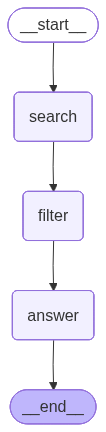

In [110]:
from langgraph.graph import StateGraph
from IPython.display import Image, display


builder = StateGraph(AgentState)

builder.add_node("search", search_node)
builder.add_node("filter", filter_node)
builder.add_node("answer", answer_node)

builder.set_entry_point("search")

builder.add_edge("search", "filter")
builder.add_edge("filter", "answer")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [111]:
result = graph.invoke({
    "query": "latest macbook specs 2026"
})

print("Answer:\n", result["answer"])
print("\nSources:")
for s in result["sources"]:
    print(s)

Answer:
 { "answer": "The latest MacBook Pro as of 2026 features the all-new M5 Pro and M5 Max chips, offering tremendous performance boosts with a new CPU that includes the world’s fastest CPU core, a next-generation GPU, and a Neural Accelerator in each core, along with higher unified memory bandwidth." }

Sources:
https://www.sellyourmac.com/mac-blog/apple-m5-macbook-air-pro-2026-specs-price-upgrade-guide.html
